
<table width="100%">
  <td style="font-size:30px;text-align:left;background-color:rgba(150, 123, 182, 0.7);font-style:italic;">
    Bernstein-Vazirani algorithm..<br>
    <span style="font-size:25px;font-style:normal;">
    Borja Álvarez Reguera & Alicia de la Varga Cabero.
    </span>
  </td>
</table>

<p style="font-size:22px; font-weight:bold;">Bernstein-Vazirani algorithm.</p>

The **Bernstein–Vazirani algorithm** is a classic example of how quantum computation can extract global information from a function with fewer queries than any classical algorithm.

Given a hidden bit string $s \in \{0,1\}^n$, we define the Boolean function

$$
f_s(x) = s \cdot x \;(\text{mod } 2)
$$

where $s \cdot x$ is the bitwise inner product (XOR sum).  
The goal of the algorithm is to **determine the hidden string** $s$ using **only one** query to the oracle that encodes $f_s$.

Classically, one would need up to $n$ evaluations of $f_s$ (one per bit of $s$) to reconstruct the string.  
Quantum mechanically, the Bernstein–Vazirani algorithm retrieves the entire string in **a single** oracle evaluation by exploiting **superposition** and **interference**.

In this task we will:
- Implement the **oracle** $U_{f_s}$.
- Build a wrapper function `bernstein_vazirani_run(s)` that prepares the circuit, applies the oracle, and measures the resulting state to reveal $s$.
- Test the algorithm with several hidden strings $s$ of different lengths $n$, and discuss the results.


In [1]:
# Import packages & classes
    # Classical Python Packages
import numpy as np
import matplotlib.pyplot as plt
    # Qiskit tools :)
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

<p style="font-size:18px; font-weight:bold;">Oracle construction.</p>

In this section, we construct the **oracle** $U_{f_s}$ associated with the function $f_s(x) = s \cdot x \;(\text{mod } 2)$, where $s$ is the hidden bit string and $x$ is the input string. The oracle acts on computational basis states as

$$
U_{f_s} |x\rangle |y\rangle = |x\rangle |y \oplus f_s(x)\rangle.
$$

If the ancilla q-bit is initialized in the state $|-\rangle = (|0\rangle - |1\rangle)/\sqrt{2}$, the oracle effectively applies a **phase flip** $(-1)^{f_s(x)}$ to each computational state $|x\rangle$, yielding

$$
U_{f_s} |x\rangle |-\rangle = (-1)^{f_s(x)} |x\rangle |-\rangle.
$$

In the Bernstein–Vazirani problem, this oracle can be implemented efficiently using a sequence of **controlled-X** (or equivalently **controlled-Z**) operations between each q-bit of the hidden string $s_i = 1$ and the ancilla q-bit.  
Thus, each bit of $s$ determines whether a **CNOT** is applied:  
- If $s_i = 1$, apply `cx(i, n)`.  
- If $s_i = 0$, do nothing.  

This construction embeds the hidden string $s$ into the oracle’s behavior, allowing the quantum circuit to extract $s$ in a **single evaluation**.

In [2]:
def oracle(qc, s, n):
    """
    Build the Bernstein–Vazirani oracle for f(x) = s*x (mod 2).
    What this oracle does is flip the phase of the state |x⟩ depending on how many bits
    are set to 1 in the same positions of s and x. If that number is even, the state
    remains unchanged; if it is odd, its phase is inverted. 
    In other words, it multiplies each |x⟩ by (-1)^(s·x), which is exactly what the 
    Bernstein-Vazirani oracle is expected to do.

    Parameters:
        qc (QuantumCircuit): The quantum circuit where the oracle will be applied.
        s (str): The hidden bit string (e.g., "1011").
        n (int): Number of input q-bits.
    """
    for i, bit in enumerate(s):
        # If s_i=1, apply a CNOT from q-bit i to the ancilla q-bit.
        if bit == '1': qc.cx(i, n)

<p style="font-size:18px; font-weight:bold;">Algorithm outline & implementation.</p>

1. **Initialization**  
   We start with $n$ input q-bits and one ancilla q-bit in the state $|0\rangle^{\otimes n}$. The ancilla is then transformed into the state $|-\rangle = (|0\rangle - |1\rangle)/\sqrt{2}$ to enable **phase kickback** from the oracle.

2. **Superposition**  
   Apply Hadamard gates to all input q-bits, creating a uniform superposition of all possible inputs:  
   $$
   \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} |x\rangle \otimes |-\rangle
   $$

3. **Oracle application**  
   The oracle $U_{f_s}$ encodes the hidden string $s$ by flipping the phase of basis states according to  
   $$
   U_{f_s} |x\rangle |-\rangle = (-1)^{s \cdot x} |x\rangle |-\rangle.
   $$
   This is implemented efficiently using **CNOT gates** controlled by each q-bit where $s_i = 1$ and targeting the ancilla.

4. **Interference and measurement**  
   Apply Hadamard gates again to all input q-bits. The **interference pattern** reconstructs the hidden string $s$: each input q-bit $i$ ends up in $|s_i\rangle$, revealing the complete secret string.  

5. **Result interpretation**  
   After measurement, the output bitstring directly corresponds to the hidden string $s$. This means that, unlike the classical approach requiring up to $n$ queries, the **Bernstein–Vazirani algorithm finds $s$ in a single oracle query**.

---

In our implementation, we first **verify that the provided secret string $s$ is valid** (only contains '0' or '1' and has length $n$). Then, we build the quantum circuit, simulate it, display the resulting circuit diagram, and interpret the measurement outcome, which should **reveal the hidden string exactly**.

In [3]:
def bernstein_vazirani_run(s, n):
    """
    Runs the Bernstein-Vazirani algorithm for a given secret string s and n input q-bits.

    Parameters:
    s (str): A bitstring of n bits
    n (int): Number of input q-bits (excluding the ancilla q-bit).
    """

    # --- Step 1: Check if s is a bitstring of n bits ---

    if not all(bit in '01' for bit in s):
        raise ValueError("Secret string 's' must contain only '0' and '1'.")

    if len(s) != n:
        raise ValueError(f"Length of secret string ({len(s)}) must match number of q-bits ({n}).")
    
    # --- Step 2: Build the quantum circuit ---

    # Create a circuit with n input q-bits and 1 ancilla q-bit, and n classical bits for measurement
    qc = QuantumCircuit(n + 1, n)

    # Initialize the ancilla q-bit in |-> = (|0> - |1>)/√2
    qc.x(n)
    qc.h(n)

    # Apply Hadamard gates to all input q-bits to create superposition
    for i in range(n): qc.h(i)
    qc.barrier()

    # --- Step 3: Apply the oracle Uf ---
    oracle(qc, s, n)
    qc.barrier()

    # --- Step 4: Apply Hadamard gates again to perform interference ---
    for i in range(n): qc.h(i)

    # --- Step 5: Measure all input q-bits ---
    for i in range(n): qc.measure(i, i)

    # --- Step 6: Simulate the circuit (1 shot is enough) ---
    counts = AerSimulator().run(qc, shots=1).result().get_counts()

    # --- Step 7: Interpret the result ---
    
    # The only measured bitstring should be the secret bitstring s
    output = list(counts.keys())[0]
    # Qiskit returns bitstrings with q-bit 0 (first bit) as the least significant bit.
    # We invert the order to match the original secret string s.
    output = output[::-1]  
    print(f"The hidden bitstring is: {output}")

    # Display the circuit
    display(qc.draw('mpl'))
    return qc, counts

<p style="font-size:18px; font-weight:bold;">Testing the algorithm.</p>

Now that the **Bernstein–Vazirani algorithm** and its oracle have been implemented, it is time to verify that the function correctly reveals the hidden string and handles invalid input gracefully.

We will test several hidden strings $s$ of different lengths $n$, including both valid bitstrings and invalid cases to ensure that the input validation works correctly.

The following test cases will be considered:
1. Secret string $s = 00 \ $ ($n=2$) – valid.
2. Secret string $s = 01 \ $ ($n=2$) – valid.
3. Secret string $s = 101 \ $ ($n=3$) – valid.
4. Secret string $s = 210 \ $ ($n=3$) – invalid: contains a non-binary digit.
5. Secret string $s = 1100 \ $ ($n=3$) – invalid: length does not match number of q-bits.
6. Secret string $s = 11010 \ $ ($n=5$) – valid.

We expect:
- The algorithm to **correctly output the hidden string** for valid cases.
- The invalid cases to **raise an error** before constructing the quantum circuit, preventing execution with improper input.


--- Testing: s=00, n=2 ---
The hidden bitstring is: 00


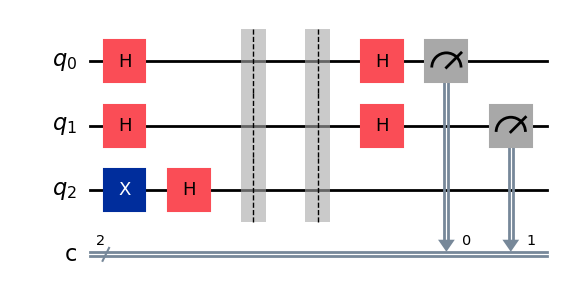


--- Testing: s=01, n=2 ---
The hidden bitstring is: 01


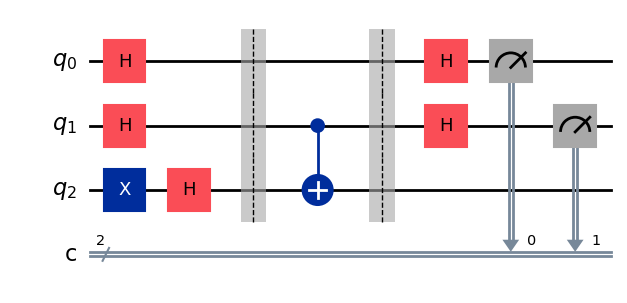


--- Testing: s=101, n=3 ---
The hidden bitstring is: 101


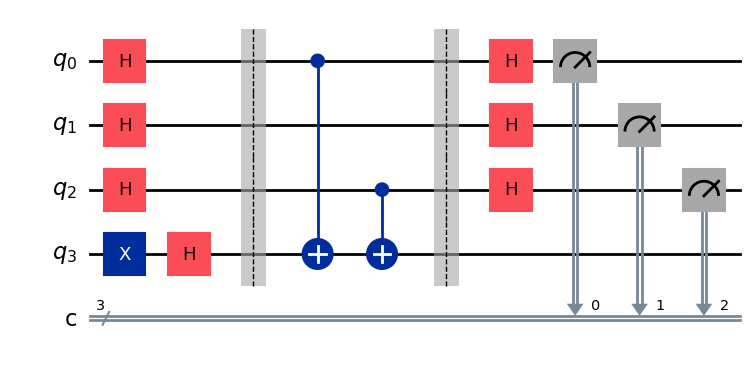


--- Testing: Invalid (not a bitstring), n=3 ---
Error detected: Secret string 's' must contain only '0' and '1'.

--- Testing: Invalid (len(s) is not n), n=3 ---
Error detected: Length of secret string (4) must match number of q-bits (3).

--- Testing: s=11010, n=5 ---
The hidden bitstring is: 11010


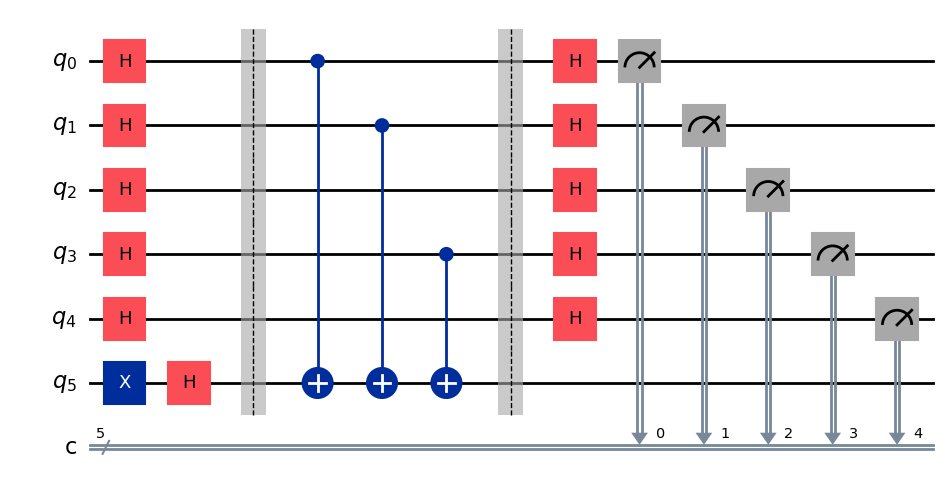

In [4]:
# --- Run tests ---
test_cases = [
    ('00', 2, "s=00"),
    ('01', 2, "s=01"),
    ('101', 3, "s=101"),
    ('210', 3, "Invalid (not a bitstring)"),
    ('1100', 3, "Invalid (len(s) is not n)"),
    ('11010', 5, "s=11010"),
]

for s, n, desc in test_cases:
    print(f"\n--- Testing: {desc}, n={n} ---")
    try:
        qc, counts = bernstein_vazirani_run(s, n)
    except ValueError as e:
        print("Error detected:", e)